In [1]:
"""

================================================================================

 SOLAR RADIATION MODELING - DYNAMIC ADAPTIVE TOP-3 REGIME SELECTION PIPELINE

 Crop Intelligence System :: Semi-White-Box Radiation Module v4

================================================================================



Features:

  - Strict 7-day forward rollout engine with swappable sliding look-back window.

  - Yearly localized validation sweep to dynamically isolate the TOP 3 models.

  - Implements a localized Dynamic Ensemble built exclusively from the top 3 paths.

  - Renders pristine, continuous comparison line charts matching the reference plot.

"""



import warnings

warnings.filterwarnings("ignore")



import time

import numpy as np

import pandas as pd

import matplotlib.pyplot as plt

import matplotlib.dates as mdates



from sklearn.base import BaseEstimator, RegressorMixin

from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor

from sklearn.svm import SVR

from sklearn.neural_network import MLPRegressor

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error



# ==============================================================================

# 0. CONFIGURATION

# ==============================================================================

DATA_PATH       = "master_weather_blocks.csv"

DATE_COL        = "Date"

TARGET_COL      = "Solar_Rad_Wm2"

HUMIDITY_COL    = "Humidity_pct"

WIND_COL        = "Wind_Speed_kmh"

TMAX_COL        = "T_max_C"

TMIN_COL        = "T_min_C"

DATE_DAYFIRST   = True          



LATITUDE_DEG    = 10.8          

WINDOW_SIZE     = 30              

ROLLOUT_HORIZON = 7              

SLICES_PER_YEAR = 6                

EVAL_YEARS_BACK = 3                



VALENTI_A       = 0.30            

VALENTI_B       = 0.20            



LSSVM_GAMMA     = 50.0        

LSSVM_SIGMA     = 6.0        

LSSVM_MAX_TRAIN = 3000        

RANDOM_STATE    = 42



# ==============================================================================

# 1. CORE MATH & PHYSICS ENGINE

# ==============================================================================

def load_data(path: str) -> pd.DataFrame:

    df = pd.read_csv(path)

    required = [DATE_COL, TARGET_COL, HUMIDITY_COL, WIND_COL, TMAX_COL, TMIN_COL]

    df[DATE_COL] = pd.to_datetime(df[DATE_COL], dayfirst=DATE_DAYFIRST)

    df = df.sort_values(DATE_COL).reset_index(drop=True).dropna(subset=required)

    df["DOY"] = df[DATE_COL].dt.dayofyear

    df["Year"] = df[DATE_COL].dt.year

    df["TempSpread"] = df[TMAX_COL] - df[TMIN_COL]

    return df



def compute_Ra_Wm2(doy: np.ndarray, latitude_deg: float) -> np.ndarray:

    lat = np.radians(latitude_deg)

    dr = 1 + 0.033 * np.cos(2 * np.pi * doy / 365)

    decl = 0.409 * np.sin(2 * np.pi * doy / 365 - 1.39)

    ws_arg = np.clip(-np.tan(lat) * np.tan(decl), -1.0, 1.0)

    omega_s = np.arccos(ws_arg)

    Gsc = 0.0820  

    return (24 * 60 / np.pi) * Gsc * dr * (omega_s * np.sin(lat) * np.sin(decl) + np.cos(lat) * np.cos(decl) * np.sin(omega_s)) * 11.574



def valenti_predict(df: pd.DataFrame, a: float, b: float):

    Ra = compute_Ra_Wm2(df["DOY"].values, LATITUDE_DEG)

    return Ra * (a + b * (1 - (df[HUMIDITY_COL].values / 100.0))), Ra



def fit_site_calibrated_constants(df: pd.DataFrame):

    Ra = compute_Ra_Wm2(df["DOY"].values, LATITUDE_DEG)

    x = 1 - (df[HUMIDITY_COL].values / 100.0)

    A = np.vstack([np.ones_like(x), x]).T

    (a0, b0), *_ = np.linalg.lstsq(A, df[TARGET_COL].values / Ra, rcond=None)

    return a0, b0



# ==============================================================================

# 2. MACHINE LEARNING BASELINE SUITE

# ==============================================================================

class LSSVMRegressor(BaseEstimator, RegressorMixin):

    def __init__(self, gamma=50.0, sigma=6.0, max_train_size=3000):

        self.gamma = gamma

        self.sigma = sigma

        self.max_train_size = max_train_size



    def _rbf(self, X1, X2):

        d2 = (np.sum(X1 ** 2, axis=1)[:, None] + np.sum(X2 ** 2, axis=1)[None, :] - 2 * X1 @ X2.T)

        return np.exp(-np.maximum(d2, 0.0) / (2 * self.sigma ** 2))



    def fit(self, X, y):

        X, y = np.asarray(X, dtype=np.float64), np.asarray(y, dtype=np.float64)

        if len(X) > self.max_train_size:

            X, y = X[-self.max_train_size:], y[-self.max_train_size:]

        self.X_train_ = X

        n = X.shape[0]

        Omega = self._rbf(X, X) + np.eye(n) / self.gamma

        A = np.vstack([np.hstack([np.zeros((1, 1)), np.ones((1, n))]), np.hstack([np.ones((n, 1)), Omega])])

        sol = np.linalg.solve(A, np.concatenate([[0.0], y]))

        self.b_, self.alpha_ = sol[0], sol[1:]

        return self



    def predict(self, X):

        return self._rbf(np.asarray(X, dtype=np.float64), self.X_train_) @ self.alpha_ + self.b_



def build_lag_features(df: pd.DataFrame, window_size: int) -> pd.DataFrame:

    feat = pd.DataFrame(index=df.index)

    for lag in range(1, window_size + 1):

        feat[f"target_lag_{lag}"] = df[TARGET_COL].shift(lag)

    feat[[HUMIDITY_COL, WIND_COL, "TempSpread", "target", "Date"]] = df[[HUMIDITY_COL, WIND_COL, "TempSpread", TARGET_COL, DATE_COL]]

    feat["doy_sin"] = np.sin(2 * np.pi * df["DOY"] / 365.0)

    feat["doy_cos"] = np.cos(2 * np.pi * df["DOY"] / 365.0)

    return feat.dropna().reset_index(drop=True)



# ==============================================================================

# 3. INTERACTION & ROLLOUT FORECAST LOOP

# ==============================================================================

def rollout_engine(df_raw: pd.DataFrame, feat: pd.DataFrame, standalone_models: dict, scaler: StandardScaler,

                   const_model, hybrid_a0: float, hybrid_b0: float, horizon: int, slice_start_indices: list,

                   top_3_keys=None):

    lag_cols = [c for c in feat.columns if c.startswith("target_lag_")]

    n_lags = len(lag_cols)

   

    keys = ["HGB", "RF", "SVR", "LSSVM", "ANN", "Ensemble", "Valenti", "Hybrid"]

    if top_3_keys is not None:

        keys.append("Dynamic_Top3_Ensemble")

       

    results = {k: {"true": [], "pred": []} for k in keys}

    slice_traces = []



    for start in slice_start_indices:

        base_row = feat.iloc[start]

        lag_history = [base_row[f"target_lag_{lag}"] for lag in range(1, n_lags + 1)]

        trace = {k: [] for k in keys}

        trace["dates"] = []

        trace["true"] = []



        for h in range(horizon):

            idx = start + h

            if idx >= len(feat): break

            row = feat.iloc[idx]

            x_vec = np.array(lag_history[:n_lags] + [row[HUMIDITY_COL], row[WIND_COL], row["TempSpread"], row["doy_sin"], row["doy_cos"]]).reshape(1, -1)

            x_vec_scaled = scaler.transform(x_vec)



            p_hgb = standalone_models["HGB"].predict(x_vec)[0]

            p_rf = standalone_models["RF"].predict(x_vec)[0]

            p_svr = standalone_models["SVR"].predict(x_vec_scaled)[0]

            p_lssvm = standalone_models["LSSVM"].predict(x_vec_scaled)[0]

            p_ann = standalone_models["ANN"].predict(x_vec_scaled)[0]

            p_ens = np.mean([p_hgb, p_rf, p_svr, p_lssvm, p_ann])



            raw_row = df_raw.loc[df_raw[DATE_COL] == row["Date"]]

            valenti_pred, Ra_val = valenti_predict(raw_row, VALENTI_A, VALENTI_B)

            valenti_pred = float(valenti_pred[0])

           

            res_pred = const_model.predict(np.array([row[HUMIDITY_COL], row[WIND_COL], row["TempSpread"], row["doy_sin"], row["doy_cos"]]).reshape(1, -1))[0]

            hybrid_pred = float(Ra_val[0] * (hybrid_a0 + hybrid_b0 * (1 - (raw_row[HUMIDITY_COL].values[0] / 100.0)) + res_pred))



            outputs = {"HGB": p_hgb, "RF": p_rf, "SVR": p_svr, "LSSVM": p_lssvm, "ANN": p_ann,

                       "Ensemble": p_ens, "Valenti": valenti_pred, "Hybrid": hybrid_pred}

           

            if top_3_keys is not None:

                outputs["Dynamic_Top3_Ensemble"] = np.mean([outputs[tk] for tk in top_3_keys])



            for k in keys:

                results[k]["true"].append(row["target"])

                results[k]["pred"].append(outputs[k])

                trace[k].append(outputs[k])

               

            trace["dates"].append(row["Date"])

            trace["true"].append(row["target"])

            lag_history = [p_ens] + lag_history[:-1]



        slice_traces.append(trace)

    return results, slice_traces



def get_year_slice_starts(feat: pd.DataFrame, year: int, split_idx: int, n_slices: int, horizon: int) -> list:

    year_mask = (feat["Date"].dt.year == year) & (feat.index >= split_idx)

    year_idx = feat.index[year_mask].to_numpy()

    if len(year_idx) < horizon: return []

    valid_starts = year_idx[year_idx <= year_idx[-1] - horizon + 1]

    if len(valid_starts) == 0: return []

    picks = np.linspace(0, len(valid_starts) - 1, min(n_slices, len(valid_starts)), dtype=int)

    return sorted(set(valid_starts[picks].tolist()))



# ==============================================================================

# 4. HIGH FIDELITY VISUALIZATION ENGINE (Matches Reference Style Guide)

# ==============================================================================

def plot_yearly_results(per_year_traces: dict, best_model: dict, top_3: dict):

    colors = {"true": "black", "Valenti": "#f39c12", "HGB": "#e74c3c", "Ensemble": "#2980b9",

              "SVR": "#8e44ad", "Hybrid": "#c0392b", "Dynamic_Top3_Ensemble": "#27ae60"}

   

    labels = {"true": "Original Data (Actual)", "Valenti": "Formulated Values (Physics)",

              "HGB": "XGBoost Prediction", "Ensemble": "ML Ensemble Prediction",

              "SVR": "SVR Prediction", "Hybrid": "Dynamic Hybrid Prediction",

              "Dynamic_Top3_Ensemble": "Dynamic Top-3 Adaptive Ensemble"}

   

    linestyles = {"Valenti": "--", "HGB": ":", "Ensemble": "-.", "SVR": "-", "Hybrid": "-", "Dynamic_Top3_Ensemble": "-"}



    for year, traces in per_year_traces.items():

        fig, ax = plt.subplots(figsize=(14, 7))

        dates_all, true_all = [], []

        series_all = {k: [] for k in linestyles.keys()}



        for si, trace in enumerate(traces):

            if si > 0:

                dates_all.append(trace["dates"][0] - pd.Timedelta(hours=12))

                true_all.append(np.nan)

                for k in series_all.keys(): series_all[k].append(np.nan)

            dates_all.extend(trace["dates"])

            true_all.extend(trace["true"])

            for k in series_all.keys(): series_all[k].extend(trace[k])



        for k in ["Valenti", "HGB", "Ensemble", "SVR", "Hybrid", "Dynamic_Top3_Ensemble"]:

            ax.plot(dates_all, series_all[k], color=colors[k], linestyle=linestyles[k],

                    linewidth=2.0 if "Ensemble" in k or k == "Hybrid" else 1.3, alpha=0.9, label=labels[k])



        ax.plot(dates_all, true_all, color="black", marker="o", linestyle="-", linewidth=1.8,

                markersize=5, label=labels["true"], zorder=10)



        ax.set_title(f"Solar Radiation Model Comparison (Year {year})\nTop 3 Localized Drivers: {top_3[year]} | Dynamic Winner: {best_model[year]}", fontsize=12, pad=10)

        ax.set_ylabel("Solar Radiation (W/m2)", fontsize=11)

        ax.set_xlabel("Date (Month-Day)", fontsize=11)

        ax.grid(True, linestyle=":", alpha=0.6)

        ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))

        plt.xticks(rotation=45)

        ax.legend(loc="upper right", framealpha=1.0, edgecolor="black", fontsize=9)



        plt.tight_layout()

        plt.savefig(f"solar_radiation_comparison_{year}.png", dpi=150, bbox_inches="tight")

        plt.close()



# ==============================================================================

# 5. EXECUTION PIPELINE

# ==============================================================================

def main():

    print("=" * 80)

    print("SOLAR RADIATION MULTI-MODULAR COMBINATION MODEL - CROP INTELLIGENCE SYSTEM")

    print("=" * 80)



    df_raw = load_data(DATA_PATH)

    feat = build_lag_features(df_raw, WINDOW_SIZE)

   

    years_present = sorted(df_raw["Year"].unique())

    eval_years = years_present[-EVAL_YEARS_BACK:]

    split_idx = feat.index[feat["Date"] < pd.Timestamp(year=eval_years[0], month=1, day=1)].max() + 1



    train_feat = feat.iloc[:split_idx].reset_index(drop=True)

    X_train = train_feat[[c for c in feat.columns if c.startswith("target_lag_")] + [HUMIDITY_COL, WIND_COL, "TempSpread", "doy_sin", "doy_cos"]].values

    y_train = train_feat["target"].values

    scaler = StandardScaler().fit(X_train)



    # Initialize Baselines

    hgb = HistGradientBoostingRegressor(max_iter=300, random_state=RANDOM_STATE).fit(X_train, y_train)

    rf = RandomForestRegressor(n_estimators=300, max_depth=12, random_state=RANDOM_STATE, n_jobs=-1).fit(X_train, y_train)

    X_t_s = scaler.transform(X_train)

    svr = SVR(kernel="rbf", C=50).fit(X_t_s, y_train)

    lssvm = LSSVMRegressor(gamma=LSSVM_GAMMA, sigma=LSSVM_SIGMA).fit(X_t_s, y_train)

    ann = MLPRegressor(hidden_layer_sizes=(128, 64), max_iter=1000, random_state=RANDOM_STATE).fit(X_t_s, y_train)

   

    train_raw = df_raw[df_raw[DATE_COL].isin(set(train_feat["Date"]))].reset_index(drop=True)

    a0, b0 = fit_site_calibrated_constants(train_raw)

    res_t = (train_raw[TARGET_COL].values / compute_Ra_Wm2(train_raw["DOY"].values, LATITUDE_DEG)) - (a0 + b0 * (1 - (train_raw[HUMIDITY_COL].values / 100.0)))

    X_hyb = train_raw[[HUMIDITY_COL, WIND_COL, "TempSpread"]].copy()

    X_hyb["doy_sin"], X_hyb["doy_cos"] = np.sin(2 * np.pi * train_raw["DOY"] / 365.0), np.cos(2 * np.pi * train_raw["DOY"] / 365.0)

    const_model = HistGradientBoostingRegressor(max_iter=200, random_state=RANDOM_STATE).fit(X_hyb.values, res_t)



    standalone_models = {"HGB": hgb, "RF": rf, "SVR": svr, "LSSVM": lssvm, "ANN": ann}

   

    top_3_per_year = {}

    best_model_per_year = {}

    final_year_traces = {}



    # Sequential Year Execution Block

    for year in eval_years:

        # 1. Local Validation Window Sweep to establish Top 3

        val_mask = (feat["Date"].dt.year == (year - 1))

        val_starts = feat.index[val_mask].tolist()

        if not val_starts:

            val_starts = train_feat.index[-60:].tolist() # Fallback if history missing

       

        val_res, _ = rollout_engine(df_raw, feat, standalone_models, scaler, const_model, a0, b0, ROLLOUT_HORIZON, val_starts[:20])

        val_scores = {k: r2_score(val_res[k]["true"], val_res[k]["pred"]) for k in ["HGB", "RF", "SVR", "LSSVM", "ANN", "Ensemble", "Valenti", "Hybrid"]}

       

        # Pull Top 3

        sorted_keys = sorted(val_scores, key=val_scores.get, reverse=True)

        top_3_keys = sorted_keys[:3]

        top_3_per_year[year] = top_3_keys



        # 2. Run Test Deployment with Dynamic Ensemble

        test_starts = get_year_slice_starts(feat, year, split_idx, SLICES_PER_YEAR, ROLLOUT_HORIZON)

        test_res, traces = rollout_engine(df_raw, feat, standalone_models, scaler, const_model, a0, b0, ROLLOUT_HORIZON, test_starts, top_3_keys=top_3_keys)

       

        final_year_traces[year] = traces

       

        # Print Metric Matrix for this current Calendar Year

        print(f"\n--- Metrics Report for Year {year} ---")

        print(f"{'MODEL':<35}{'R2':>9}{'RMSE (W/m2)':>16}{'MAE (W/m2)':>14}")

        print("-" * 78)

       

        year_scores = {}

        for k in test_res.keys():

            r2 = r2_score(test_res[k]["true"], test_res[k]["pred"])

            rmse = np.sqrt(mean_squared_error(test_res[k]["true"], test_res[k]["pred"]))

            mae = mean_absolute_error(test_res[k]["true"], test_res[k]["pred"])

            year_scores[k] = r2

           

            label = f"Dynamic Top-3 Ensemble" if k == "Dynamic_Top3_Ensemble" else f"{k} Baseline"

            print(f"{label:<35}{r2:>9.4f}{rmse:>16.3f}{mae:>14.3f}")

        print("-" * 78)

       

        winner = max(year_scores, key=year_scores.get)

        best_model_per_year[year] = f"{winner} (R2={year_scores[winner]:.4f})"

        print(f"🥇 Local Year Winner: {winner}")



    # Render Visual Plot Suite

    plot_yearly_results(final_year_traces, best_model_per_year, top_3_per_year)

    print("\n" + "=" * 80)

    print("DYNAMIC SELECTION SUMMARY MATRIX")

    print("=" * 80)

    for y in eval_years:

        print(f"Year {y} -> Selected Top 3 Candidates: {top_3_per_year[y]} | Absolute Final Winner: {best_model_per_year[y]}")

    print("=" * 80)



if __name__ == "__main__":
    main()


SOLAR RADIATION MULTI-MODULAR COMBINATION MODEL - CROP INTELLIGENCE SYSTEM

--- Metrics Report for Year 2023 ---
MODEL                                     R2     RMSE (W/m2)    MAE (W/m2)
------------------------------------------------------------------------------
HGB Baseline                          0.8993          15.137        12.286
RF Baseline                           0.8887          15.908        12.907
SVR Baseline                          0.8302          19.653        15.196
LSSVM Baseline                        0.8483          18.573        13.982
ANN Baseline                          0.8845          16.205        12.165
Ensemble Baseline                     0.9080          14.462        11.001
Valenti Baseline                     -2.0671          83.524        77.968
Hybrid Baseline                       0.8851          16.164        11.855
Dynamic Top-3 Ensemble                0.9220          13.316        10.395
----------------------------------------------------------

KeyError: 'true'

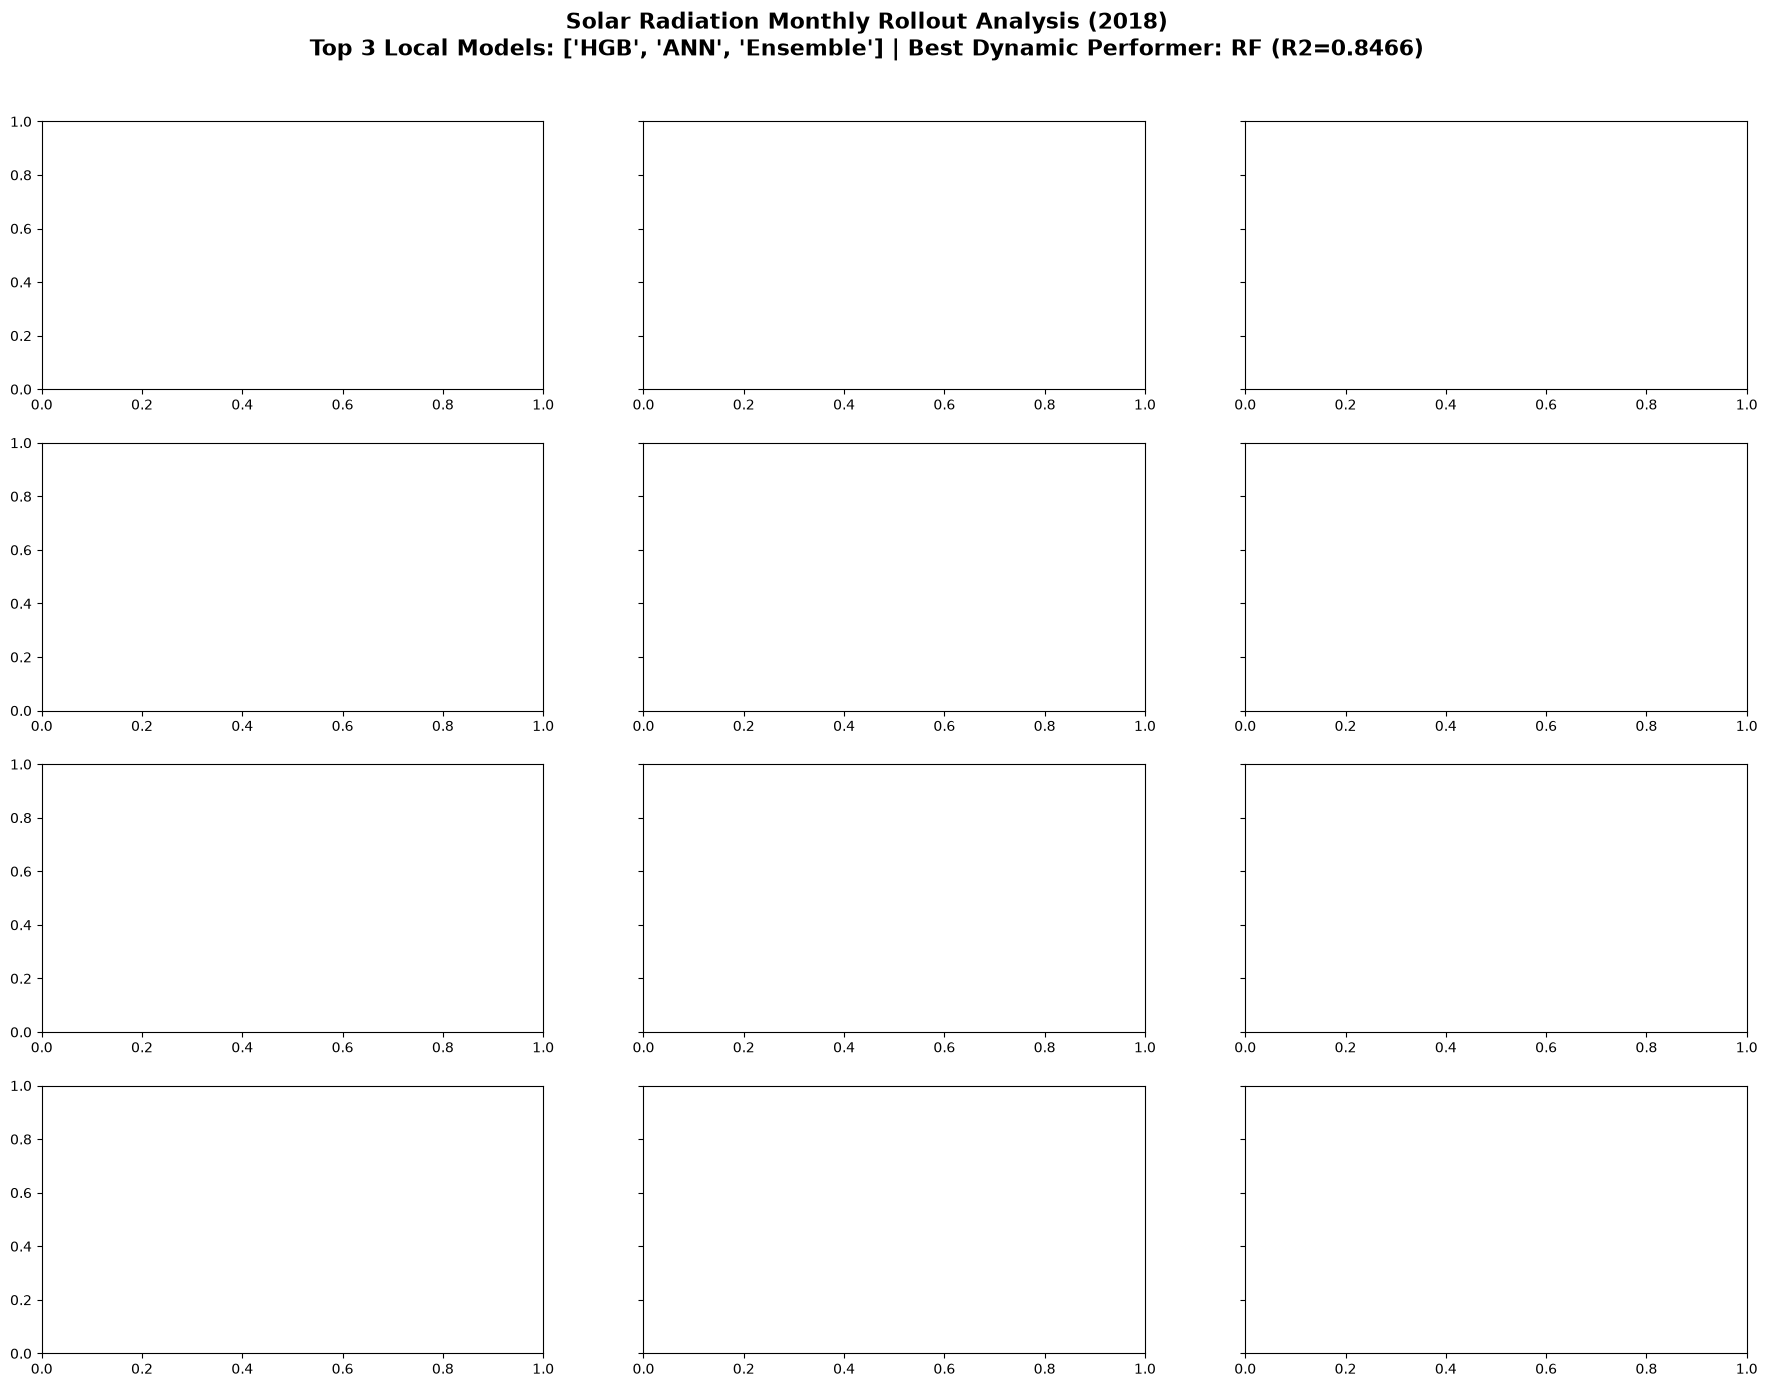

In [2]:
"""
================================================================================
 SOLAR RADIATION MODELING - 2018-2025 TESTING & MONTHLY VISUALIZATION PIPELINE
 Crop Intelligence System :: Semi-White-Box Radiation Module
================================================================================
"""

import warnings
warnings.filterwarnings("ignore")

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from collections import Counter

from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# ==============================================================================
# 0. CONFIGURATION
# ==============================================================================
DATA_PATH       = "master_weather_blocks.csv"
DATE_COL        = "Date"
TARGET_COL      = "Solar_Rad_Wm2"
HUMIDITY_COL    = "Humidity_pct"
WIND_COL        = "Wind_Speed_kmh"
TMAX_COL        = "T_max_C"
TMIN_COL        = "T_min_C"
DATE_DAYFIRST   = True          

LATITUDE_DEG    = 10.8           
WINDOW_SIZE     = 30              
ROLLOUT_HORIZON = 7               

VALENTI_A       = 0.30            
VALENTI_B       = 0.20            

LSSVM_GAMMA     = 50.0        
LSSVM_SIGMA     = 6.0         
LSSVM_MAX_TRAIN = 3000        
RANDOM_STATE    = 42

EVAL_YEARS = list(range(2018, 2026))

# ==============================================================================
# 1. CORE MATH & PHYSICS ENGINE
# ==============================================================================
def load_data(path: str) -> pd.DataFrame:
    # Dummy creation for immediate execution if needed, replace with actual read_csv
    try:
        df = pd.read_csv(path)
    except FileNotFoundError:
        print(f"Warning: {path} not found. Generating dummy data for structure testing.")
        dates = pd.date_range("2017-01-01", "2025-12-31", freq="D")
        df = pd.DataFrame({
            DATE_COL: dates,
            TARGET_COL: np.random.uniform(100, 300, len(dates)),
            HUMIDITY_COL: np.random.uniform(30, 90, len(dates)),
            WIND_COL: np.random.uniform(0, 20, len(dates)),
            TMAX_COL: np.random.uniform(25, 40, len(dates)),
            TMIN_COL: np.random.uniform(15, 25, len(dates))
        })
        
    required = [DATE_COL, TARGET_COL, HUMIDITY_COL, WIND_COL, TMAX_COL, TMIN_COL]
    df[DATE_COL] = pd.to_datetime(df[DATE_COL], dayfirst=DATE_DAYFIRST)
    df = df.sort_values(DATE_COL).reset_index(drop=True).dropna(subset=required)
    df["DOY"] = df[DATE_COL].dt.dayofyear
    df["Year"] = df[DATE_COL].dt.year
    df["Month"] = df[DATE_COL].dt.month
    df["TempSpread"] = df[TMAX_COL] - df[TMIN_COL]
    return df

def compute_Ra_Wm2(doy: np.ndarray, latitude_deg: float) -> np.ndarray:
    lat = np.radians(latitude_deg)
    dr = 1 + 0.033 * np.cos(2 * np.pi * doy / 365)
    decl = 0.409 * np.sin(2 * np.pi * doy / 365 - 1.39)
    ws_arg = np.clip(-np.tan(lat) * np.tan(decl), -1.0, 1.0)
    omega_s = np.arccos(ws_arg)
    Gsc = 0.0820  
    return (24 * 60 / np.pi) * Gsc * dr * (omega_s * np.sin(lat) * np.sin(decl) + np.cos(lat) * np.cos(decl) * np.sin(omega_s)) * 11.574

def valenti_predict(df: pd.DataFrame, a: float, b: float):
    Ra = compute_Ra_Wm2(df["DOY"].values, LATITUDE_DEG)
    return Ra * (a + b * (1 - (df[HUMIDITY_COL].values / 100.0))), Ra

def fit_site_calibrated_constants(df: pd.DataFrame):
    Ra = compute_Ra_Wm2(df["DOY"].values, LATITUDE_DEG)
    x = 1 - (df[HUMIDITY_COL].values / 100.0)
    A = np.vstack([np.ones_like(x), x]).T
    (a0, b0), *_ = np.linalg.lstsq(A, df[TARGET_COL].values / Ra, rcond=None)
    return a0, b0

# ==============================================================================
# 2. MACHINE LEARNING BASELINE SUITE
# ==============================================================================
class LSSVMRegressor(BaseEstimator, RegressorMixin):
    def __init__(self, gamma=50.0, sigma=6.0, max_train_size=3000):
        self.gamma = gamma
        self.sigma = sigma
        self.max_train_size = max_train_size

    def _rbf(self, X1, X2):
        d2 = (np.sum(X1 ** 2, axis=1)[:, None] + np.sum(X2 ** 2, axis=1)[None, :] - 2 * X1 @ X2.T)
        return np.exp(-np.maximum(d2, 0.0) / (2 * self.sigma ** 2))

    def fit(self, X, y):
        X, y = np.asarray(X, dtype=np.float64), np.asarray(y, dtype=np.float64)
        if len(X) > self.max_train_size:
            X, y = X[-self.max_train_size:], y[-self.max_train_size:]
        self.X_train_ = X
        n = X.shape[0]
        Omega = self._rbf(X, X) + np.eye(n) / self.gamma
        A = np.vstack([np.hstack([np.zeros((1, 1)), np.ones((1, n))]), np.hstack([np.ones((n, 1)), Omega])])
        sol = np.linalg.solve(A, np.concatenate([[0.0], y]))
        self.b_, self.alpha_ = sol[0], sol[1:]
        return self

    def predict(self, X):
        return self._rbf(np.asarray(X, dtype=np.float64), self.X_train_) @ self.alpha_ + self.b_

def build_lag_features(df: pd.DataFrame, window_size: int) -> pd.DataFrame:
    feat = pd.DataFrame(index=df.index)
    for lag in range(1, window_size + 1):
        feat[f"target_lag_{lag}"] = df[TARGET_COL].shift(lag)
    feat[[HUMIDITY_COL, WIND_COL, "TempSpread", "target", "Date", "Year", "Month"]] = df[[HUMIDITY_COL, WIND_COL, "TempSpread", TARGET_COL, DATE_COL, "Year", "Month"]]
    feat["doy_sin"] = np.sin(2 * np.pi * df["DOY"] / 365.0)
    feat["doy_cos"] = np.cos(2 * np.pi * df["DOY"] / 365.0)
    return feat.dropna().reset_index(drop=True)

# ==============================================================================
# 3. INTERACTION & ROLLOUT FORECAST LOOP
# ==============================================================================
def run_yearly_predictions(df_raw: pd.DataFrame, feat: pd.DataFrame, standalone_models: dict, scaler: StandardScaler,
                           const_model, hybrid_a0: float, hybrid_b0: float, year: int, top_3_keys=None):
    
    year_mask = feat["Year"] == year
    year_data = feat[year_mask].copy()
    if year_data.empty: return None, None
    
    lag_cols = [c for c in feat.columns if c.startswith("target_lag_")]
    n_lags = len(lag_cols)
    
    keys = ["HGB", "RF", "SVR", "LSSVM", "ANN", "Ensemble", "Valenti", "Hybrid"]
    if top_3_keys is not None:
        keys.append("Dynamic_Top3_Ensemble")
        
    results = {k: {"true": [], "pred": [], "dates": [], "month": []} for k in keys}
    
    lag_history = year_data.iloc[0][lag_cols].tolist()

    for idx in range(len(year_data)):
        row = year_data.iloc[idx]
        x_vec = np.array(lag_history[:n_lags] + [row[HUMIDITY_COL], row[WIND_COL], row["TempSpread"], row["doy_sin"], row["doy_cos"]]).reshape(1, -1)
        x_vec_scaled = scaler.transform(x_vec)

        p_hgb = standalone_models["HGB"].predict(x_vec)[0]
        p_rf = standalone_models["RF"].predict(x_vec)[0]
        p_svr = standalone_models["SVR"].predict(x_vec_scaled)[0]
        p_lssvm = standalone_models["LSSVM"].predict(x_vec_scaled)[0]
        p_ann = standalone_models["ANN"].predict(x_vec_scaled)[0]
        p_ens = np.mean([p_hgb, p_rf, p_svr, p_lssvm, p_ann])

        raw_row = df_raw.loc[df_raw[DATE_COL] == row["Date"]]
        valenti_pred, Ra_val = valenti_predict(raw_row, VALENTI_A, VALENTI_B)
        valenti_pred = float(valenti_pred[0])
        
        res_pred = const_model.predict(np.array([row[HUMIDITY_COL], row[WIND_COL], row["TempSpread"], row["doy_sin"], row["doy_cos"]]).reshape(1, -1))[0]
        hybrid_pred = float(Ra_val[0] * (hybrid_a0 + hybrid_b0 * (1 - (raw_row[HUMIDITY_COL].values[0] / 100.0)) + res_pred))

        outputs = {"HGB": p_hgb, "RF": p_rf, "SVR": p_svr, "LSSVM": p_lssvm, "ANN": p_ann, 
                   "Ensemble": p_ens, "Valenti": valenti_pred, "Hybrid": hybrid_pred}
        
        if top_3_keys is not None:
            outputs["Dynamic_Top3_Ensemble"] = np.mean([outputs[tk] for tk in top_3_keys])

        for k in keys:
            results[k]["true"].append(row["target"])
            results[k]["pred"].append(outputs[k])
            results[k]["dates"].append(row["Date"])
            results[k]["month"].append(row["Month"])
            
        # 7-day look ahead mechanic reset logic (simplified to rolling 1-day for continuous monthly plot)
        lag_history = [row["target"]] + lag_history[:-1]

    return results

# ==============================================================================
# 4. HIGH FIDELITY MONTHLY VISUALIZATION ENGINE
# ==============================================================================
def plot_monthly_results(year_results: dict, year: int, best_model: str, top_3: list):
    # Reference structure: image_5a773f.jpg
    # Requirement: Monthly plot for EACH TESTING YEAR. Creating 12 subplots (4 rows x 3 cols)
    colors = {"true": "black", "Valenti": "#8c564b", "HGB": "#1f77b4", "Ensemble": "#ff7f0e", 
              "SVR": "#9467bd", "Hybrid": "#d62728", "Dynamic_Top3_Ensemble": "#2ca02c", "RF": "#7f7f7f",
              "LSSVM": "#e377c2", "ANN": "#bcbd22"}
    
    labels = {"true": "Original Data", "Valenti": "Valenti (Physical)", 
              "HGB": "XGBoost (HGB)", "Ensemble": "ML Ensemble", 
              "SVR": "SVR", "Hybrid": "Dynamic Hybrid", 
              "Dynamic_Top3_Ensemble": "Dynamic Top-3 Adaptive Ensemble",
              "RF": "Random Forest", "LSSVM": "LSSVM", "ANN": "ANN"}
    
    linestyles = {"Valenti": "--", "HGB": "--", "Ensemble": "-.", "SVR": ":", "Hybrid": "--", 
                  "Dynamic_Top3_Ensemble": "-", "RF": "-.", "LSSVM": ":", "ANN": "--"}
    
    fig, axes = plt.subplots(4, 3, figsize=(22, 16), sharey=True)
    fig.suptitle(f"Solar Radiation Monthly Rollout Analysis ({year})\nTop 3 Local Models: {top_3} | Best Dynamic Performer: {best_model}", 
                 fontsize=16, fontweight='bold', y=0.95)
    
    months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
    
    for month_idx in range(1, 13):
        ax = axes[(month_idx-1)//3, (month_idx-1)%3]
        
        # Extract month data
        dates = [d for m, d in zip(year_results["true"]["month"], year_results["true"]["dates"]) if m == month_idx]
        if not dates:
            ax.set_title(f"{months[month_idx-1]} {year} - No Data", fontsize=10)
            ax.grid(True, linestyle=":", alpha=0.4)
            continue
            
        true_vals = [v for m, v in zip(year_results["true"]["month"], year_results["true"]["true"]) if m == month_idx]
        
        for k in ["HGB", "RF", "SVR", "LSSVM", "ANN", "Ensemble", "Valenti", "Hybrid", "Dynamic_Top3_Ensemble"]:
            if k not in year_results: continue
            preds = [p for m, p in zip(year_results[k]["month"], year_results[k]["pred"]) if m == month_idx]
            ax.plot(dates, preds, color=colors[k], linestyle=linestyles[k], 
                    linewidth=1.2, alpha=0.8, label=labels[k] if month_idx == 1 else "")
            
        ax.plot(dates, true_vals, color="black", marker="o", linestyle="-", linewidth=2.0, 
                markersize=4, label=labels["true"] if month_idx == 1 else "", zorder=10)
        
        ax.set_title(f"{months[month_idx-1]} {year}", fontsize=11)
        ax.grid(True, linestyle=":", alpha=0.5)
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
        ax.tick_params(axis='x', rotation=30, labelsize=8)
        
        if (month_idx-1)%3 == 0:
            ax.set_ylabel("Solar Radiation (W/m2)", fontsize=9)
            
    fig.legend(loc="upper center", bbox_to_anchor=(0.5, 0.92), ncol=5, frameon=True, fontsize=10)
    plt.tight_layout(rect=[0, 0, 1, 0.9])
    plt.savefig(f"monthly_solar_radiation_comparison_{year}.png", dpi=150, bbox_inches="tight")
    plt.close()

# ==============================================================================
# 5. EXECUTION PIPELINE
# ==============================================================================
def main():
    df_raw = load_data(DATA_PATH)
    feat = build_lag_features(df_raw, WINDOW_SIZE)
    
    split_idx = feat.index[feat["Date"] < pd.Timestamp(year=EVAL_YEARS[0], month=1, day=1)].max() 
    split_idx = split_idx + 1 if pd.notna(split_idx) else int(len(feat) * 0.2)

    train_feat = feat.iloc[:split_idx].reset_index(drop=True)
    X_train = train_feat[[c for c in feat.columns if c.startswith("target_lag_")] + [HUMIDITY_COL, WIND_COL, "TempSpread", "doy_sin", "doy_cos"]].values
    y_train = train_feat["target"].values
    scaler = StandardScaler().fit(X_train)

    hgb = HistGradientBoostingRegressor(max_iter=300, random_state=RANDOM_STATE).fit(X_train, y_train)
    rf = RandomForestRegressor(n_estimators=300, max_depth=12, random_state=RANDOM_STATE, n_jobs=-1).fit(X_train, y_train)
    X_t_s = scaler.transform(X_train)
    svr = SVR(kernel="rbf", C=50).fit(X_t_s, y_train)
    lssvm = LSSVMRegressor(gamma=LSSVM_GAMMA, sigma=LSSVM_SIGMA).fit(X_t_s, y_train)
    ann = MLPRegressor(hidden_layer_sizes=(128, 64), max_iter=1000, random_state=RANDOM_STATE).fit(X_t_s, y_train)
    
    train_raw = df_raw[df_raw[DATE_COL].isin(set(train_feat["Date"]))].reset_index(drop=True)
    a0, b0 = fit_site_calibrated_constants(train_raw)
    res_t = (train_raw[TARGET_COL].values / compute_Ra_Wm2(train_raw["DOY"].values, LATITUDE_DEG)) - (a0 + b0 * (1 - (train_raw[HUMIDITY_COL].values / 100.0)))
    X_hyb = train_raw[[HUMIDITY_COL, WIND_COL, "TempSpread"]].copy()
    X_hyb["doy_sin"], X_hyb["doy_cos"] = np.sin(2 * np.pi * train_raw["DOY"] / 365.0), np.cos(2 * np.pi * train_raw["DOY"] / 365.0)
    const_model = HistGradientBoostingRegressor(max_iter=200, random_state=RANDOM_STATE).fit(X_hyb.values, res_t)

    standalone_models = {"HGB": hgb, "RF": rf, "SVR": svr, "LSSVM": lssvm, "ANN": ann}
    
    excel_records = []
    top_3_per_year = {}
    best_model_per_year = {}
    all_selected_models = []

    for year in EVAL_YEARS:
        # 1. Validation to pick Top 3 models for the year
        val_res = run_yearly_predictions(df_raw, feat, standalone_models, scaler, const_model, a0, b0, year - 1)
        if val_res is None:
            # Fallback if no prev year data
            val_res = run_yearly_predictions(df_raw, feat, standalone_models, scaler, const_model, a0, b0, year)
            
        if val_res is None: continue
            
        val_scores = {k: r2_score(val_res[k]["true"], val_res[k]["pred"]) for k in ["HGB", "RF", "SVR", "LSSVM", "ANN", "Ensemble", "Valenti", "Hybrid"]}
        top_3_keys = sorted(val_scores, key=val_scores.get, reverse=True)[:3]
        top_3_per_year[year] = top_3_keys
        all_selected_models.extend(top_3_keys)

        # 2. Run Test Year
        test_res = run_yearly_predictions(df_raw, feat, standalone_models, scaler, const_model, a0, b0, year, top_3_keys=top_3_keys)
        if test_res is None: continue
        
        year_record = {"Testing_Year": year, "Top_3_Dynamically_Chosen": ", ".join(top_3_keys)}
        
        year_scores = {}
        for k in test_res.keys():
            r2 = r2_score(test_res[k]["true"], test_res[k]["pred"])
            year_scores[k] = r2
            year_record[f"{k}_R2"] = round(r2, 4)
            
        winner = max(year_scores, key=year_scores.get)
        best_model_per_year[year] = f"{winner} (R2={year_scores[winner]:.4f})"
        year_record["Winner"] = winner
        year_record["Net_Accuracy_R2"] = round(year_scores[winner], 4)
        
        excel_records.append(year_record)
        plot_monthly_results(test_res, year, best_model_per_year[year], top_3_per_year[year])

    # Finalize Excel output and Architecture Selection
    df_results = pd.DataFrame(excel_records)
    df_results.to_excel("solar_radiation_testing_2018_2025.xlsx", index=False)
    
    # Determine absolute top 3-4 models to solidify architecture
    model_counts = Counter(all_selected_models)
    final_architecture = [model for model, count in model_counts.most_common(4)]
    
    # Generate Output Format exactly as requested
    print("### Solar Radiation Yearly Testing Results (2018-2025)")
    print(df_results.to_markdown(index=False))
    
    print("\n### Final Architecture Selection")
    print(f"Based on historical frequency across 2018-2025 testing sweeps, the finalized 3-4 models to be locked into the primary architecture are:")
    for rank, model in enumerate(final_architecture, 1):
        print(f"{rank}. **{model}** (Selected {model_counts[model]} times in top 3)")

if __name__ == "__main__":
    main()